In [158]:
import os
import numpy as np
import matplotlib.pyplot as plt
from os.path import join
from PIL import Image
from glob import glob
import random

In [159]:
nnUNet_raw = "data/nnUNet_raw"
nnUNet_preprocessed = "data/nUNet_preprocessed"

os.environ["nnUNet_raw"] = nnUNet_raw
os.environ["nnUNet_preprocessed"] = nnUNet_preprocessed

In [160]:
def get_dataset_name(dataset_id):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [
        d for d in os.listdir(nnUNet_raw)
        if d.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, d))
    ]
    if len(dataset_name) != 1:
        raise RuntimeError(f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1")
    return dataset_name[0]

# Task Difficulty Index

## Target Geometry

### Compactness

In [202]:
from skimage.measure import label, regionprops

def compute_compactness(target):
    '''
    Compactness C = (4 * pi * A) / P^2
    Input: target mask (0, 1, 2, ...)
    '''
    labeled = label(target)
    compactness_vals = []

    for region in regionprops(labeled):
        area = region.area
        if area == 0:
            continue

        perimeter = region.perimeter
        c = (4 * np.pi * area) / (perimeter ** 2 + 1e-6)
        compactness_vals.append(c)

    return compactness_vals


target: (512, 512)
[np.float64(0.5860271177735134), np.float64(0.44756442371607846), np.float64(0.3618951550145613), np.float64(0.7463629110999329), np.float64(0.9869910164880897), np.float64(0.952533951418165)]


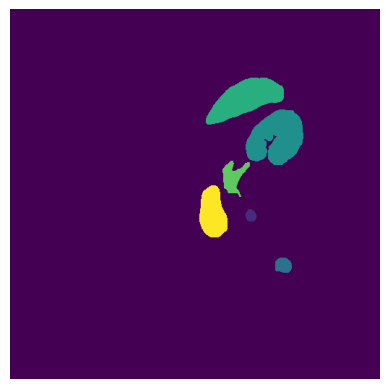

In [332]:
dataset_id = 305
dataset_name = get_dataset_name(dataset_id)

targets = glob(join(nnUNet_raw, dataset_name, "labelsTr", "*.png"))
# num_cases = 100
# targets = targets[:num_cases]
random.shuffle(targets)
for target_path in targets:
    target = np.array(Image.open(target_path))
    print("target:", target.shape)
    compactness = compute_compactness(target)
    print(compactness)
    plt.imshow(target)
    plt.axis('off')
    plt.show()
    break

## Target variability

## Target - Image mutual information